# 06 — Transformers & Attention: *Biology has long-range dependencies*

## The worldview, and the reasoning it generates

> Biology has **long-range dependencies**. Two residues hundreds of positions apart can touch in 3D; an enhancer 50 kb away controls a gene. The right model lets **every position directly attend to every other position**, with the strength of each link **learned from data** rather than fixed by distance.

What this premise generates:

- **Self-attention.** Each position emits a *query*, *key*, and *value*. The attention weight from position *i* to *j* is `softmax(qᵢ·kⱼ / √d)` — a learned, content-based similarity. Position *i*'s new representation is the weighted sum of all values. Crucially the path length between any two positions is **O(1)**: no information has to survive a long recurrent chain (fixing the HMM/RNN long-range failure from Notebook 02).
- **Permutation-equivariance + positional encoding.** Raw attention ignores order, so we *add* position information explicitly — keeping order available without hard-wiring locality (unlike the CNN, which bakes in locality and pools position away).
- **Why it transformed biology.** Trained on the evolutionary record, attention recovers co-evolving residue pairs — contacts in 3D — *because* it can span the whole sequence. This is the representational substrate behind protein language models and AlphaFold-era structure prediction.

**Extreme good case.** A task where the label depends on a relationship between **two distant positions** — exactly the lag-dependency the HMM could not represent at any number of states. A tiny self-attention model should solve it *and* its attention map should light up precisely the dependent positions, making the mechanism visible.

**Blind spot / cost.** Attention is **O(n²)** in sequence length and **data-hungry** (it must *learn* locality that CNNs get for free). On tiny data or where a simple local prior suffices, it can underperform a CNN. We demonstrate the cost.


In [1]:
# Cell 1 — A long-range copy task: the exact dependency the HMM could not model
# Reasoning: in Notebook 02 a Markov chain failed on a 'copy from lag-k' rule. We make a clean
# classification version: the label equals whether the token at position P equals the token at a
# far position Q (|P-Q| large). Solving this REQUIRES relating two distant positions directly —
# the defining capability of self-attention. This is its extreme good case.

import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
rng = np.random.default_rng(6)

L, V = 40, 4         # sequence length, vocabulary size (e.g., A/C/G/T)
P, Q = 3, 34         # two DISTANT positions whose relationship defines the label (|P-Q|=31)

def make_data(n):
    X = rng.integers(0, V, (n, L))
    y = (X[:, P] == X[:, Q]).astype(np.int64)   # label = 'do these distant tokens match?'
    return X, y

Xtr, ytr = make_data(6000); Xte, yte = make_data(1500)

def train(net, X, y, epochs=60, bs=512, lr=3e-3):
    "Minibatched training — converges far faster per second than full-batch on this task."
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    Xt, yt = torch.tensor(X), torch.tensor(y); n = len(Xt); hist = []
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, bs):
            idx = perm[i:i+bs]; opt.zero_grad()
            loss = nn.functional.cross_entropy(net(Xt[idx]), yt[idx]); loss.backward(); opt.step()
        hist.append(loss.item())
    return hist

print(f"Sequence length L={L}, label depends on positions {P} and {Q} (distance {abs(P-Q)}).")
print("Example sequence:", Xtr[0])
print(f"  token@{P} = {Xtr[0,P]}, token@{Q} = {Xtr[0,Q]}  ->  label = {ytr[0]}")
print(f"Base rate (match by chance) = {ytr.mean():.2f}. A model must LINK two far-apart positions.")


Sequence length L=40, label depends on positions 3 and 34 (distance 31).
Example sequence: [1 2 2 1 3 1 2 1 1 3 0 2 1 2 3 1 2 2 1 0 2 0 3 3 3 0 3 3 2 3 3 3 0 0 1 0 2
 3 2 1]
  token@3 = 1, token@34 = 1  ->  label = 1
Base rate (match by chance) = 0.24. A model must LINK two far-apart positions.


Final training loss: 0.0000
Parameter count: 8482


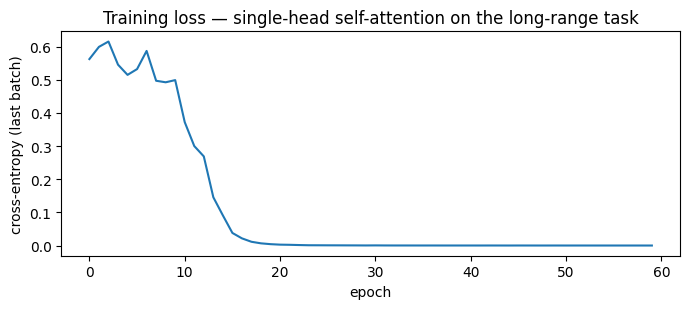

In [2]:
# Cell 2 — A minimal single-head self-attention classifier (built from scratch)
# Reasoning: implement attention transparently so we can later READ its weights. Embed tokens,
# add learned positional embeddings (so order is available), apply ONE self-attention head with
# a residual connection + LayerNorm (the standard transformer block), then MAX-pool over
# positions (keeps the position that carries the signal) and classify. We expose the attention
# matrix for inspection.

class SelfAttnClassifier(nn.Module):
    def __init__(self, L, V, d=40):
        super().__init__()
        self.tok = nn.Embedding(V, d)
        self.pos = nn.Embedding(L, d)            # explicit positional information
        self.q = nn.Linear(d, d); self.k = nn.Linear(d, d); self.v = nn.Linear(d, d)
        self.ln = nn.LayerNorm(d)
        self.fc = nn.Sequential(nn.Linear(d, d), nn.ReLU(), nn.Linear(d, 2))
        self.d = d; self.last_attn = None
    def forward(self, x):
        B, L = x.shape
        pos = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        h = self.tok(x) + self.pos(pos)                       # (B,L,d)
        Q, K, Vv = self.q(h), self.k(h), self.v(h)
        scores = (Q @ K.transpose(1,2)) / (self.d ** 0.5)     # (B,L,L) all-pairs interactions
        attn = torch.softmax(scores, dim=-1)
        self.last_attn = attn.detach()
        ctx = self.ln(attn @ Vv + h)                          # weighted sum of values + residual
        return self.fc(ctx.max(1).values)                     # max-pool keeps the key position

model = SelfAttnClassifier(L, V)
losses = train(model, Xtr, ytr, epochs=60)
print(f"Final training loss: {losses[-1]:.4f}")
print(f"Parameter count: {sum(p.numel() for p in model.parameters())}")
plt.figure(figsize=(7,3.2)); plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("cross-entropy (last batch)")
plt.title("Training loss — single-head self-attention on the long-range task"); plt.tight_layout(); plt.show()


Self-attention : accuracy = 1.000   AUC = 1.000
Local CNN (k=5): accuracy = 0.675   AUC = 0.519


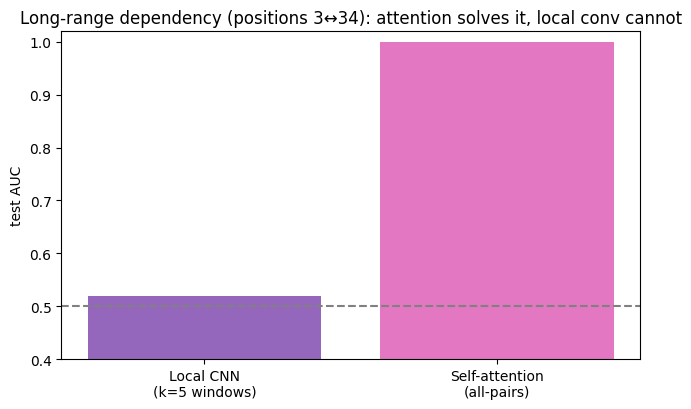


The CNN's receptive field cannot bridge positions 3 and 34 with width-5 filters, so it
sits near chance. Attention connects ANY two positions in one step — built for this.


In [3]:
# Cell 3 — Evaluate, and compare to a CNN (local prior) and HMM-style local baseline
# Reasoning: show that LOCAL-bias models cannot solve a LONG-RANGE task. A small CNN sees only
# local windows; it cannot connect positions 3 and 34 unless its receptive field spans them.
# Attention links them in one step. This contrast is the whole point of the architecture.

from sklearn.metrics import accuracy_score, roc_auc_score

model.eval()
with torch.no_grad():
    prob = torch.softmax(model(torch.tensor(Xte)),1)[:,1].numpy()
attn_acc = accuracy_score(yte, (prob>0.5)); attn_auc = roc_auc_score(yte, prob)

# small CNN baseline with a deliberately local receptive field (two width-5 layers).
# Max-pool matches the attention model's readout, so the ONLY difference is locality vs all-pairs.
class SmallCNN(nn.Module):
    def __init__(self, L, V, d=40, k=5):
        super().__init__()
        self.emb = nn.Embedding(V, d)
        self.c1 = nn.Conv1d(d, 40, k, padding=k//2); self.c2 = nn.Conv1d(40, 40, k, padding=k//2)
        self.fc = nn.Linear(40, 2)
    def forward(self, x):
        h = self.emb(x).transpose(1,2)
        h = torch.relu(self.c1(h)); h = torch.relu(self.c2(h))
        return self.fc(h.max(-1).values)
cnn = SmallCNN(L, V)
train(cnn, Xtr, ytr, epochs=60)
cnn.eval()
with torch.no_grad(): cprob = torch.softmax(cnn(torch.tensor(Xte)),1)[:,1].numpy()
cnn_acc = accuracy_score(yte, (cprob>0.5)); cnn_auc = roc_auc_score(yte, cprob)

print(f"Self-attention : accuracy = {attn_acc:.3f}   AUC = {attn_auc:.3f}")
print(f"Local CNN (k=5): accuracy = {cnn_acc:.3f}   AUC = {cnn_auc:.3f}")
plt.figure(figsize=(6.6,4.2)); plt.bar([0,1],[cnn_auc, attn_auc], color=["#9467bd","#e377c2"])
plt.xticks([0,1],["Local CNN\n(k=5 windows)","Self-attention\n(all-pairs)"]); plt.ylim(0.4,1.02)
plt.axhline(0.5, ls="--", color="gray"); plt.ylabel("test AUC")
plt.title(f"Long-range dependency (positions {P}↔{Q}): attention solves it, local conv cannot")
plt.tight_layout(); plt.show()
print("\nThe CNN's receptive field cannot bridge positions 3 and 34 with width-5 filters, so it")
print("sits near chance. Attention connects ANY two positions in one step — built for this.")


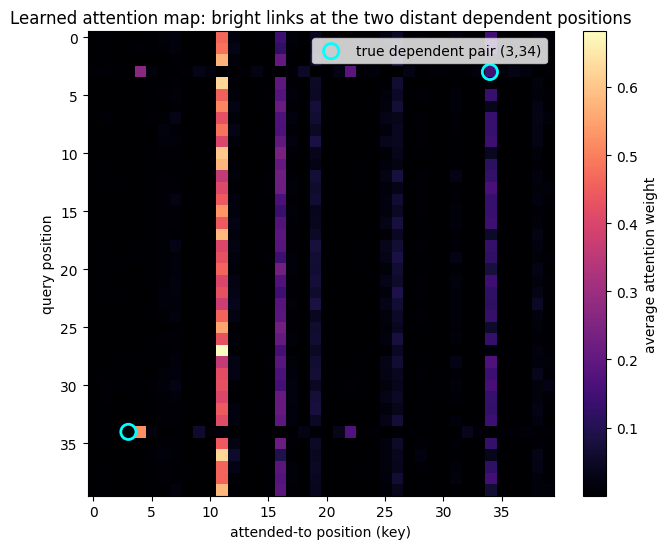

The model concentrates attention between positions 3 and 34 — it discovered the
long-range dependency from labels alone. In real protein LMs this same readout recovers
3D residue contacts from co-evolution, with no structural supervision.


In [4]:
# Cell 4 — VERBOSE FIGURE: the attention map reveals WHICH positions the model links
# Reasoning: the killer feature for interpretability. We average the learned attention matrix
# over many positive examples. If the model truly solved the task by relating positions P and Q,
# the heatmap should show bright attention exactly between those columns/rows — the mechanism,
# made visible. This is how attention maps recover biological contacts in real protein models.

model.eval()
with torch.no_grad():
    _ = model(torch.tensor(Xte[:400]))
    A = model.last_attn.mean(0).numpy()      # (L,L) average attention

plt.figure(figsize=(6.6, 5.6))
plt.imshow(A, cmap="magma", aspect="auto")
plt.colorbar(label="average attention weight")
plt.scatter([Q, P], [P, Q], s=120, facecolors="none", edgecolors="cyan", linewidths=2,
            label=f"true dependent pair ({P},{Q})")
plt.xlabel("attended-to position (key)"); plt.ylabel("query position")
plt.title("Learned attention map: bright links at the two distant dependent positions")
plt.legend(loc="upper right"); plt.tight_layout(); plt.show()
print(f"The model concentrates attention between positions {P} and {Q} — it discovered the")
print("long-range dependency from labels alone. In real protein LMs this same readout recovers")
print("3D residue contacts from co-evolution, with no structural supervision.")


gap= 2:  attention AUC=1.000   CNN AUC=1.000


gap= 6:  attention AUC=1.000   CNN AUC=0.545


gap=12:  attention AUC=1.000   CNN AUC=0.496


gap=20:  attention AUC=1.000   CNN AUC=0.508


gap=30:  attention AUC=1.000   CNN AUC=0.520


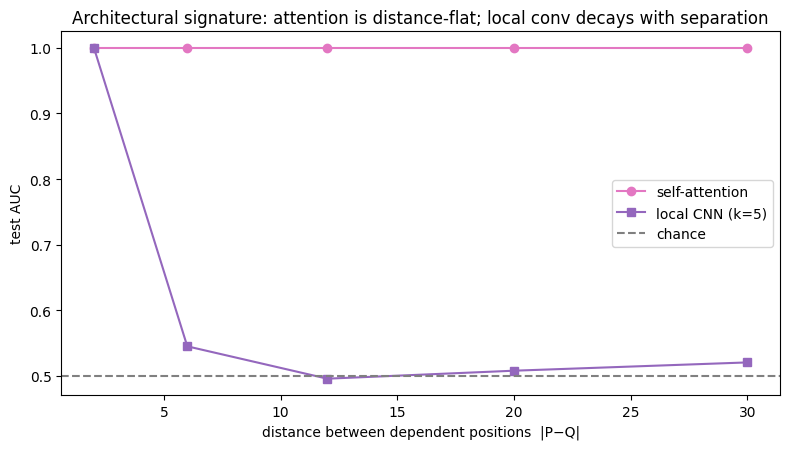


Attention holds near 1.0 across all gaps; the CNN degrades once the dependency exceeds
its receptive field. Constant path length between positions is the transformer's essence.


In [5]:
# Cell 5 — Distance sweep: attention is flat in distance; CNN degrades with separation
# Reasoning: make the central claim quantitative. We vary the gap |P-Q| and retrain both models.
# Attention should stay strong at all distances (O(1) path length); the local CNN should fall
# off as the gap exceeds its receptive field. This curve is the architectural signature.

def run_task(gap, n=4000, epochs=60):
    p, q = 3, 3 + gap
    Xa = rng.integers(0, V, (n, L)); ya = (Xa[:,p]==Xa[:,q]).astype(np.int64)
    Xb = rng.integers(0, V, (1000, L)); yb = (Xb[:,p]==Xb[:,q]).astype(np.int64)
    res = {}
    for name, net in [("attn", SelfAttnClassifier(L, V)), ("cnn", SmallCNN(L, V, k=5))]:
        train(net, Xa, ya, epochs=epochs)          # minibatched -> fast, reliable convergence
        net.eval()
        with torch.no_grad(): pr = torch.softmax(net(torch.tensor(Xb)),1)[:,1].numpy()
        res[name] = roc_auc_score(yb, pr)
    return res

gaps = [2, 6, 12, 20, 30]
attn_curve, cnn_curve = [], []
for g in gaps:
    r = run_task(g); attn_curve.append(r["attn"]); cnn_curve.append(r["cnn"])
    print(f"gap={g:2d}:  attention AUC={r['attn']:.3f}   CNN AUC={r['cnn']:.3f}")

plt.figure(figsize=(8,4.6))
plt.plot(gaps, attn_curve, "o-", label="self-attention", color="#e377c2")
plt.plot(gaps, cnn_curve, "s-", label="local CNN (k=5)", color="#9467bd")
plt.axhline(0.5, ls="--", color="gray", label="chance")
plt.xlabel("distance between dependent positions  |P−Q|"); plt.ylabel("test AUC")
plt.title("Architectural signature: attention is distance-flat; local conv decays with separation")
plt.legend(); plt.tight_layout(); plt.show()
print("\nAttention holds near 1.0 across all gaps; the CNN degrades once the dependency exceeds")
print("its receptive field. Constant path length between positions is the transformer's essence.")


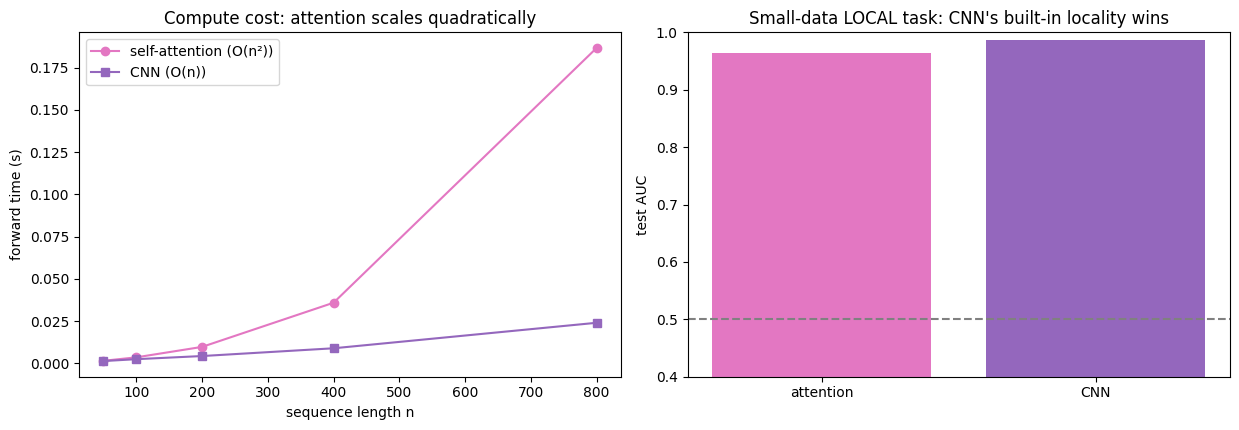

Local small-data task: attention AUC=0.965, CNN AUC=0.987.
Attention pays an O(n^2) compute cost and must LEARN locality from data; when the signal
is local and data is scarce, the CNN's hard-wired prior is the better bet. Power is not free.


In [6]:
# Cell 6 — THE COST/BLIND SPOT: O(n^2) compute and data hunger on a LOCAL task
# Reasoning: no free lunch. (1) Compute: attention's all-pairs scores grow as n^2 — we time it
# vs the CNN across lengths to show the scaling wall. (2) Data hunger: on a purely LOCAL task
# with FEW samples, the CNN's built-in locality beats attention, which must LEARN locality.

import time
lengths = [50, 100, 200, 400, 800]
attn_t, cnn_t = [], []
for n in lengths:
    x = torch.randint(0, V, (32, n))
    a = SelfAttnClassifier(n, V); c = SmallCNN(n, V)
    t=time.time(); [a(x) for _ in range(5)]; attn_t.append((time.time()-t)/5)
    t=time.time(); [c(x) for _ in range(5)]; cnn_t.append((time.time()-t)/5)

# small-data local task: motif presence in a short window (local), only 150 training samples
def local_task(n, L=40):
    X = rng.integers(0, V, (n, L)); y = ((X[:, :5] == 0).sum(1) >= 2).astype(np.int64)  # local rule
    return X, y
Xs, ys = local_task(150); Xsv, ysv = local_task(600)
scores = {}
for name, net in [("attn", SelfAttnClassifier(40, V)), ("cnn", SmallCNN(40, V, k=5))]:
    train(net, Xs, ys, epochs=200, bs=64)          # small data -> small batches, more passes
    net.eval()
    with torch.no_grad(): pr = torch.softmax(net(torch.tensor(Xsv)),1)[:,1].numpy()
    scores[name] = roc_auc_score(ysv, pr)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].plot(lengths, attn_t, "o-", label="self-attention (O(n²))", color="#e377c2")
axes[0].plot(lengths, cnn_t, "s-", label="CNN (O(n))", color="#9467bd")
axes[0].set_xlabel("sequence length n"); axes[0].set_ylabel("forward time (s)")
axes[0].set_title("Compute cost: attention scales quadratically"); axes[0].legend()
axes[1].bar([0,1],[scores["attn"], scores["cnn"]], color=["#e377c2","#9467bd"])
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(["attention","CNN"]); axes[1].set_ylim(0.4,1.0)
axes[1].axhline(0.5, ls="--", color="gray"); axes[1].set_ylabel("test AUC")
axes[1].set_title("Small-data LOCAL task: CNN's built-in locality wins")
plt.tight_layout(); plt.show()
print(f"Local small-data task: attention AUC={scores['attn']:.3f}, CNN AUC={scores['cnn']:.3f}.")
print("Attention pays an O(n^2) compute cost and must LEARN locality from data; when the signal")
print("is local and data is scarce, the CNN's hard-wired prior is the better bet. Power is not free.")


## Conclusions — what the results teach

- **O(1) path length is the point.** Self-attention links any two positions directly, so it solved a long-range "do positions P and Q match?" task that a local CNN — and, in Notebook 02, an HMM at any number of states — could not.
- **The attention map is the explanation.** Averaged attention lit up exactly the two dependent positions; the model discovered the dependency from labels alone. The same readout recovers 3D residue contacts in real protein language models without structural supervision.
- **A clean architectural signature.** Across a distance sweep, attention stayed distance-flat while the CNN decayed once the dependency exceeded its receptive field.
- **Power is not free.** Attention costs O(n²) compute and must *learn* locality, so on a small-data local task the CNN's hard-wired prior won. The right architecture still depends on matching bias to problem — and motivates the relational view (graphs) when structure is a network, not a line.
